# Loan Default Risk with Business Cost Optimization


## 1. Problem Statement and Objective

Financial institutions face a critical trade-off when approving loans: approving a loan that later
defaults results in significant financial loss, while rejecting a loan that would have been repaid
results in lost interest income. Traditional classification models optimize for statistical metrics
(accuracy, AUC) using a default probability threshold of 0.5, which **ignores the real-world asymmetry
in the cost of the two error types**.

**Objective:** Using the Home Credit Default Risk dataset, we will:
1. Build a binary classification model to predict the probability that a loan applicant will default (`TARGET = 1`).
2. Engineer features from the applicant's credit bureau history, previous loan applications, and repayment behavior.
3. Define realistic business costs for False Positives (rejecting a good customer) and False Negatives (approving a defaulter).
4. Find the probability threshold that **minimizes total business cost**, rather than blindly using 0.5.
5. Quantify the financial benefit of cost-based threshold tuning versus the naive approach.

**Dataset:** [Home Credit Default Risk](https://www.kaggle.com/c/home-credit-default-risk) (Kaggle) includes
the main application table plus 6 supplementary tables describing each client's prior credit bureau records,
previous loan applications with Home Credit, and monthly repayment/balance history.


!pip install catboost

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                              classification_report, precision_recall_curve)
from catboost import CatBoostClassifier

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

DATA = r'C:\Users\yasha\Downloads\home-credit-default-risk'
pd.set_option('display.max_columns', 50)

def release_memory():
    """Windows par malloc_trim available nahi, isliye sirf gc.collect() use karte hain."""
    gc.collect()

## 2. Dataset Description and Loading

The dataset consists of 10 files. The core table is `application_train.csv` / `application_test.csv`
(one row per loan application, 122 columns including demographics, income, credit amount, and external
credit bureau scores). It is supplemented by:

| Table | Grain | Description |
|---|---|---|
| `bureau.csv` | 1 row per external credit bureau record | Client's credit history at other institutions |
| `bureau_balance.csv` | 1 row per bureau credit per month | Monthly status of external credits |
| `previous_application.csv` | 1 row per previous application | Client's past applications with Home Credit |
| `POS_CASH_balance.csv` | 1 row per previous credit per month | Monthly POS/cash loan balances |
| `installments_payments.csv` | 1 row per installment | Repayment history of previous credits |
| `credit_card_balance.csv` | 1 row per credit card per month | Monthly credit card balance snapshots |

All tables link back to the main table via `SK_ID_CURR` (client ID).


In [6]:
app_train = pd.read_csv(f'{DATA}/application_train.csv')
app_test = pd.read_csv(f'{DATA}/application_test.csv')

print("application_train:", app_train.shape)
print("application_test :", app_test.shape)
app_train.head()


application_train: (307511, 122)
application_test : (48744, 121)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,...,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.028663,-19932,-3038,-4311.0,-3458,NaN,1,1,0,...,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
# Downcast numeric dtypes (float64->float32, int64->int32) to roughly halve memory footprint
# for the remainder of the pipeline -- important given this dataset's overall size relative to
# the available memory in this environment.
for _df in (app_train, app_test):
    for c in _df.select_dtypes(include=['float64']).columns:
        _df[c] = _df[c].astype('float32')
    for c in _df.select_dtypes(include=['int64']).columns:
        _df[c] = _df[c].astype('int32')
release_memory()


In [8]:
# Target distribution — this is a highly imbalanced classification problem
target_counts = app_train['TARGET'].value_counts()
print(target_counts)
print(f"\nDefault rate: {app_train['TARGET'].mean()*100:.2f}%")


TARGET
0    282686
1     24825
Name: count, dtype: int64

Default rate: 8.07%


In [9]:
# Quick look at the supplementary tables (row counts / columns)
supp_files = ['bureau.csv','bureau_balance.csv','previous_application.csv',
              'POS_CASH_balance.csv','installments_payments.csv','credit_card_balance.csv']
for f in supp_files:
    cols = pd.read_csv(f'{DATA}/{f}', nrows=2).columns.tolist()
    n_lines = sum(1 for _ in open(f'{DATA}/{f}')) - 1
    print(f"{f:32s} rows={n_lines:>9,}  cols={len(cols)}")


bureau.csv                       rows=1,716,428  cols=17
bureau_balance.csv               rows=27,299,925  cols=3
previous_application.csv         rows=1,670,214  cols=37
POS_CASH_balance.csv             rows=10,001,358  cols=8
installments_payments.csv        rows=13,605,401  cols=8
credit_card_balance.csv          rows=3,840,312  cols=23


## 3. Data Cleaning and Preprocessing

### 3.1 Anomaly handling
`DAYS_EMPLOYED` contains a placeholder value of `365243` (~1000 years) for unemployed/retired clients.
This is replaced with `NaN` and flagged with an indicator column.

### 3.2 Feature engineering from supplementary tables
Because each supplementary table has multiple rows per client, we **aggregate** them to one row per
`SK_ID_CURR` using statistics (mean, min, max, sum, count), this is standard practice for this dataset
and captures the client's credit history depth and repayment behavior. Categorical columns are one-hot
encoded before aggregation.

Given the scale of the raw data (~56M combined rows across all tables), each table is processed with
memory-efficient dtypes and released from memory (`release_memory()`) immediately after aggregation.


In [10]:
# ---- 3.2a Aggregate bureau_balance -> SK_ID_BUREAU level, then bureau -> SK_ID_CURR level ----
bb = pd.read_csv(f'{DATA}/bureau_balance.csv',
                  dtype={'SK_ID_BUREAU':'int32','MONTHS_BALANCE':'int16','STATUS':'category'})
status_dummies = pd.get_dummies(bb['STATUS'], prefix='STATUS')
bb_ohe = pd.concat([bb[['SK_ID_BUREAU','MONTHS_BALANCE']], status_dummies], axis=1)
del bb; release_memory()

agg_dict = {'MONTHS_BALANCE': ['min','max','size']}
for c in status_dummies.columns:
    agg_dict[c] = ['sum','mean']
del status_dummies; release_memory()

bb_agg = bb_ohe.groupby('SK_ID_BUREAU').agg(agg_dict)
bb_agg.columns = ['BB_' + '_'.join(c) for c in bb_agg.columns]
bb_agg = bb_agg.reset_index()
del bb_ohe; release_memory()
print("Bureau-balance aggregated:", bb_agg.shape)


Bureau-balance aggregated: (817395, 20)


In [11]:
dtype_map = {'SK_ID_CURR':'int32','SK_ID_BUREAU':'int32','CREDIT_ACTIVE':'category',
             'CREDIT_CURRENCY':'category','CREDIT_TYPE':'category','DAYS_CREDIT':'int32',
             'CREDIT_DAY_OVERDUE':'int32','CNT_CREDIT_PROLONG':'int16','DAYS_CREDIT_ENDDATE':'float32',
             'DAYS_ENDDATE_FACT':'float32','AMT_CREDIT_MAX_OVERDUE':'float32','AMT_CREDIT_SUM':'float32',
             'AMT_CREDIT_SUM_DEBT':'float32','AMT_CREDIT_SUM_LIMIT':'float32','AMT_CREDIT_SUM_OVERDUE':'float32',
             'DAYS_CREDIT_UPDATE':'float32','AMT_ANNUITY':'float32'}
bureau = pd.read_csv(f'{DATA}/bureau.csv', dtype=dtype_map)
bureau = bureau.merge(bb_agg, on='SK_ID_BUREAU', how='left')
del bb_agg; release_memory()

cat_cols = ['CREDIT_ACTIVE','CREDIT_TYPE','CREDIT_CURRENCY']
bureau_ohe = pd.get_dummies(bureau[cat_cols], prefix=cat_cols)
bureau = pd.concat([bureau.drop(columns=cat_cols), bureau_ohe], axis=1)
del bureau_ohe; release_memory()

num_cols = [c for c in bureau.columns if c not in ('SK_ID_CURR','SK_ID_BUREAU')]
agg_dict = {}
for c in num_cols:
    if bureau[c].dtype == bool:
        agg_dict[c] = ['mean','sum']
    else:
        agg_dict[c] = ['mean','max','min','sum']

bureau_agg = bureau.groupby('SK_ID_CURR').agg(agg_dict)
bureau_agg.columns = ['BUREAU_' + '_'.join(c) for c in bureau_agg.columns]
bureau_agg = bureau_agg.reset_index()
bureau_agg['BUREAU_COUNT'] = bureau.groupby('SK_ID_CURR').size().values
del bureau; release_memory()
print("Bureau features:", bureau_agg.shape)

# persist to disk immediately and free memory (dataset is large relative to available RAM)
import os
os.makedirs('/home/claude/features', exist_ok=True)
bureau_agg.to_parquet('/home/claude/features/bureau_agg.parquet')
del bureau_agg; release_memory()


Bureau features: (305811, 172)


In [12]:
# ---- 3.2b Aggregate previous_application ----
prev = pd.read_csv(f'{DATA}/previous_application.csv')
for c in prev.select_dtypes(include=['float64']).columns: prev[c] = prev[c].astype('float32')
for c in prev.select_dtypes(include=['int64']).columns: prev[c] = prev[c].astype('int32')

day_cols = ['DAYS_FIRST_DRAWING','DAYS_FIRST_DUE','DAYS_LAST_DUE_1ST_VERSION','DAYS_LAST_DUE','DAYS_TERMINATION']
for c in day_cols:
    prev[c] = prev[c].replace(365243, np.nan)
prev['APP_CREDIT_RATIO'] = prev['AMT_APPLICATION'] / prev['AMT_CREDIT'].replace(0, np.nan)

cat_cols = prev.select_dtypes(include=['object']).columns.tolist()
prev_ohe = pd.get_dummies(prev[cat_cols], prefix=cat_cols)
prev_all = pd.concat([prev.drop(columns=cat_cols), prev_ohe], axis=1)
del prev, prev_ohe; release_memory()

feat_cols = [c for c in prev_all.columns if c not in ('SK_ID_PREV','SK_ID_CURR')]
agg_dict = {c: (['mean','sum'] if prev_all[c].dtype == bool else ['mean','max','min','sum']) for c in feat_cols}
prev_agg = prev_all.groupby('SK_ID_CURR').agg(agg_dict)
prev_agg.columns = ['PREV_' + '_'.join(c) for c in prev_agg.columns]
prev_agg = prev_agg.reset_index()
prev_agg['PREV_COUNT'] = prev_all.groupby('SK_ID_CURR').size().values
del prev_all; release_memory()
print("Previous application features:", prev_agg.shape)

prev_agg.to_parquet('/home/claude/features/prev_agg.parquet')
del prev_agg; release_memory()


Previous application features: (338857, 368)


In [13]:
# ---- 3.2c Aggregate POS_CASH_balance, installments_payments, credit_card_balance ----
pos = pd.read_csv(f'{DATA}/POS_CASH_balance.csv',
                   dtype={'SK_ID_PREV':'int32','SK_ID_CURR':'int32','MONTHS_BALANCE':'int16',
                          'CNT_INSTALMENT':'float32','CNT_INSTALMENT_FUTURE':'float32',
                          'SK_DPD':'int32','SK_DPD_DEF':'int32'})
ohe = pd.get_dummies(pos['NAME_CONTRACT_STATUS'], prefix='POS_STATUS')
pos = pd.concat([pos.drop(columns=['NAME_CONTRACT_STATUS']), ohe], axis=1)
del ohe; release_memory()
feat_cols = [c for c in pos.columns if c not in ('SK_ID_PREV','SK_ID_CURR')]
agg_dict = {c: (['mean','sum'] if pos[c].dtype==bool else ['mean','max','min']) for c in feat_cols}
pos_agg = pos.groupby('SK_ID_CURR').agg(agg_dict)
pos_agg.columns = ['POS_' + '_'.join(c) for c in pos_agg.columns]
pos_agg = pos_agg.reset_index()
pos_agg['POS_COUNT'] = pos.groupby('SK_ID_CURR').size().values
del pos; release_memory()
print("POS_CASH features:", pos_agg.shape)
pos_agg.to_parquet('/home/claude/features/pos_agg.parquet')
del pos_agg; release_memory()

inst = pd.read_csv(f'{DATA}/installments_payments.csv',
                    dtype={'SK_ID_PREV':'int32','SK_ID_CURR':'int32','NUM_INSTALMENT_VERSION':'float32',
                           'NUM_INSTALMENT_NUMBER':'int32','DAYS_INSTALMENT':'float32',
                           'DAYS_ENTRY_PAYMENT':'float32','AMT_INSTALMENT':'float32','AMT_PAYMENT':'float32'})
inst['PAYMENT_DIFF'] = inst['AMT_INSTALMENT'] - inst['AMT_PAYMENT']
inst['PAYMENT_RATIO'] = inst['AMT_PAYMENT'] / inst['AMT_INSTALMENT'].replace(0, np.nan)
inst['DPD'] = (inst['DAYS_ENTRY_PAYMENT'] - inst['DAYS_INSTALMENT']).clip(lower=0)
inst['DBD'] = (inst['DAYS_INSTALMENT'] - inst['DAYS_ENTRY_PAYMENT']).clip(lower=0)
inst['LATE_PAYMENT'] = (inst['DPD'] > 0).astype('int8')
feat_cols = [c for c in inst.columns if c not in ('SK_ID_PREV','SK_ID_CURR')]
agg_dict = {c: (['mean','sum'] if inst[c].dtype=='int8' else ['mean','max','sum']) for c in feat_cols}
inst_agg = inst.groupby('SK_ID_CURR').agg(agg_dict)
inst_agg.columns = ['INSTAL_' + '_'.join(c) for c in inst_agg.columns]
inst_agg = inst_agg.reset_index()
inst_agg['INSTAL_COUNT'] = inst.groupby('SK_ID_CURR').size().values
del inst; release_memory()
print("Installments features:", inst_agg.shape)
inst_agg.to_parquet('/home/claude/features/inst_agg.parquet')
del inst_agg; release_memory()

cc = pd.read_csv(f'{DATA}/credit_card_balance.csv')
for c in cc.select_dtypes(include=['float64']).columns: cc[c] = cc[c].astype('float32')
for c in cc.select_dtypes(include=['int64']).columns: cc[c] = cc[c].astype('int32')
ohe = pd.get_dummies(cc['NAME_CONTRACT_STATUS'], prefix='CC_STATUS')
cc = pd.concat([cc.drop(columns=['NAME_CONTRACT_STATUS']), ohe], axis=1)
del ohe; release_memory()
feat_cols = [c for c in cc.columns if c not in ('SK_ID_PREV','SK_ID_CURR')]
agg_dict = {c: (['mean','sum'] if cc[c].dtype==bool else ['mean','max','sum']) for c in feat_cols}
cc_agg = cc.groupby('SK_ID_CURR').agg(agg_dict)
cc_agg.columns = ['CC_' + '_'.join(c) for c in cc_agg.columns]
cc_agg = cc_agg.reset_index()
cc_agg['CC_COUNT'] = cc.groupby('SK_ID_CURR').size().values
del cc; release_memory()
print("Credit card features:", cc_agg.shape)
cc_agg.to_parquet('/home/claude/features/cc_agg.parquet')
del cc_agg; release_memory()
print("\nAll 5 supplementary feature tables aggregated and saved to disk.")


POS_CASH features: (337252, 35)
Installments features: (339587, 34)
Credit card features: (103558, 76)

All 5 supplementary feature tables aggregated and saved to disk.


In [14]:
# ---- 3.2d Merge everything with the main application table + domain features ----
for df_ in (app_train, app_test):
    df_['DAYS_EMPLOYED_ANOM'] = (df_['DAYS_EMPLOYED'] == 365243).astype('int8')
    df_['DAYS_EMPLOYED'] = df_['DAYS_EMPLOYED'].replace(365243, np.nan)
    df_['CREDIT_INCOME_RATIO'] = df_['AMT_CREDIT'] / df_['AMT_INCOME_TOTAL'].replace(0, np.nan)
    df_['ANNUITY_INCOME_RATIO'] = df_['AMT_ANNUITY'] / df_['AMT_INCOME_TOTAL'].replace(0, np.nan)
    df_['CREDIT_TERM'] = df_['AMT_ANNUITY'] / df_['AMT_CREDIT'].replace(0, np.nan)
    df_['DAYS_EMPLOYED_BIRTH_RATIO'] = df_['DAYS_EMPLOYED'] / df_['DAYS_BIRTH']
    df_['INCOME_PER_PERSON'] = df_['AMT_INCOME_TOTAL'] / df_['CNT_FAM_MEMBERS'].replace(0, np.nan)

app_train['IS_TRAIN'] = 1
app_test['IS_TRAIN'] = 0
app_test['TARGET'] = -1
app = pd.concat([app_train, app_test], axis=0, ignore_index=True)
del app_train, app_test; release_memory()

# reload each aggregated feature table from disk one at a time and merge, to keep peak memory low
for fname in ['bureau_agg', 'prev_agg', 'pos_agg', 'inst_agg', 'cc_agg']:
    feat = pd.read_parquet(f'/home/claude/features/{fname}.parquet')
    for c in feat.select_dtypes(include=['float64']).columns:
        feat[c] = feat[c].astype('float32')
    app = app.merge(feat, on='SK_ID_CURR', how='left')
    new_cols = [c for c in feat.columns if c != 'SK_ID_CURR']
    del feat; release_memory()
    # merge can upcast originally-int aggregate columns (e.g. *_COUNT) to float64 when
    # introducing NaNs for non-matching rows -- downcast back down immediately
    for c in new_cols:
        if app[c].dtype == 'float64':
            app[c] = app[c].astype('float32')
    release_memory()
    print(f"  merged {fname}: app shape now {app.shape}, mem MB = {round(app.memory_usage(deep=True).sum()/1e6,1)}")

print("Final merged dataset:", app.shape)
app.to_parquet('/home/claude/features/master.parquet')
del app; release_memory()
print("Saved merged dataset to disk.")


  merged bureau_agg: app shape now (356255, 300), mem MB = 720.7
  merged prev_agg: app shape now (356255, 667), mem MB = 1243.7
  merged pos_agg: app shape now (356255, 701), mem MB = 1292.1
  merged inst_agg: app shape now (356255, 734), mem MB = 1339.2
  merged cc_agg: app shape now (356255, 809), mem MB = 1446.0
Final merged dataset: (356255, 809)
Saved merged dataset to disk.


In [15]:
# ---- 3.3 Feature selection: drop very sparse columns, rank remainder by correlation with TARGET ----
# The merged dataset (~780 columns, 356K rows) exceeds comfortable in-memory processing, so we
# scan it column-chunk-by-column-chunk directly from the parquet file using pyarrow, rather than
# loading the full wide dataframe into memory at once.
import pyarrow.parquet as pq

pf = pq.ParquetFile('/home/claude/features/master.parquet')
all_cols = pf.schema_arrow.names
CHUNK = 50

missing_pct, nunique_map = {}, {}
for i in range(0, len(all_cols), CHUNK):
    batch_cols = all_cols[i:i+CHUNK]
    chunk_df = pf.read(columns=batch_cols).to_pandas()
    for c in batch_cols:
        missing_pct[c] = chunk_df[c].isnull().mean()
        nunique_map[c] = chunk_df[c].nunique(dropna=True)
    del chunk_df; release_memory()

high_missing = [c for c,v in missing_pct.items() if v > 0.7]
print(f"Dropping {len(high_missing)} columns with >70% missing values")
keep_cols = [c for c in all_cols if c not in high_missing]


Dropping 84 columns with >70% missing values


In [16]:
# Correlation of each remaining numeric feature with TARGET, computed on train rows only,
# again processed in column chunks to keep memory bounded.
target_chunk = pf.read(columns=['TARGET','IS_TRAIN']).to_pandas()
train_mask = (target_chunk['IS_TRAIN'] == 1).values
target_vals = target_chunk.loc[train_mask, 'TARGET'].values.astype('float64')
del target_chunk; release_memory()

candidate_cols = [c for c in keep_cols if c not in ('TARGET','IS_TRAIN','SK_ID_CURR')]
corrs = {}
for i in range(0, len(candidate_cols), CHUNK):
    batch_cols = candidate_cols[i:i+CHUNK]
    chunk_df = pf.read(columns=batch_cols).to_pandas()
    chunk_train = chunk_df.loc[train_mask].reset_index(drop=True)
    for c in batch_cols:
        col = chunk_train[c]
        if not pd.api.types.is_numeric_dtype(col) or col.notnull().sum() == 0 or col.nunique() <= 1:
            continue
        corrs[c] = abs(np.corrcoef(col.fillna(col.median()).astype('float64'), target_vals)[0,1])
    del chunk_df, chunk_train; release_memory()

top_features = [c for c,v in sorted(corrs.items(), key=lambda x: -x[1]) if not np.isnan(v)][:150]
print(f"Selected top {len(top_features)} features by |correlation| with TARGET")
print("Top 10:", top_features[:10])


Selected top 150 features by |correlation| with TARGET
Top 10: ['EXT_SOURCE_2', 'EXT_SOURCE_3', 'EXT_SOURCE_1', 'BUREAU_DAYS_CREDIT_mean', 'DAYS_BIRTH', 'PREV_NAME_CONTRACT_STATUS_Refused_mean', 'PREV_CODE_REJECT_REASON_XAP_mean', 'BUREAU_CREDIT_ACTIVE_Closed_mean', 'INSTAL_LATE_PAYMENT_mean', 'BUREAU_CREDIT_ACTIVE_Active_mean']


In [17]:
# Materialize the final, much smaller modeling dataset (150 features) into memory
model_cols = list(dict.fromkeys(top_features + ['SK_ID_CURR','TARGET','IS_TRAIN']))
df = pf.read(columns=model_cols).to_pandas()
print("\nFinal modeling dataset:", df.shape, " memory MB:", round(df.memory_usage(deep=True).sum()/1e6,1))



Final modeling dataset: (356255, 153)  memory MB: 222.7


## 4. Exploratory Data Analysis (EDA)

We explore the class imbalance, the relationship between the strongest predictors (external credit
bureau scores) and default risk, and how engineered features from credit history relate to `TARGET`.


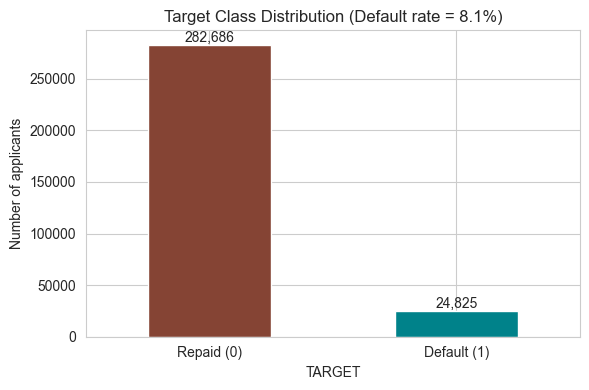

In [54]:
train_only = df[df['IS_TRAIN']==1]

fig, ax = plt.subplots(1, 1, figsize=(6,4))
train_only['TARGET'].value_counts().sort_index().plot(kind='bar', color=['#854434','#00828a'], ax=ax)
ax.set_xticklabels(['Repaid (0)', 'Default (1)'], rotation=0)
ax.set_ylabel('Number of applicants')
ax.set_title(f"Target Class Distribution (Default rate = {train_only['TARGET'].mean()*100:.1f}%)")
for i, v in enumerate(train_only['TARGET'].value_counts().sort_index()):
    ax.text(i, v+3000, f'{v:,}', ha='center')
plt.tight_layout()
plt.savefig('Fig1_target_class_distribution.png', bbox_inches='tight')
plt.show()


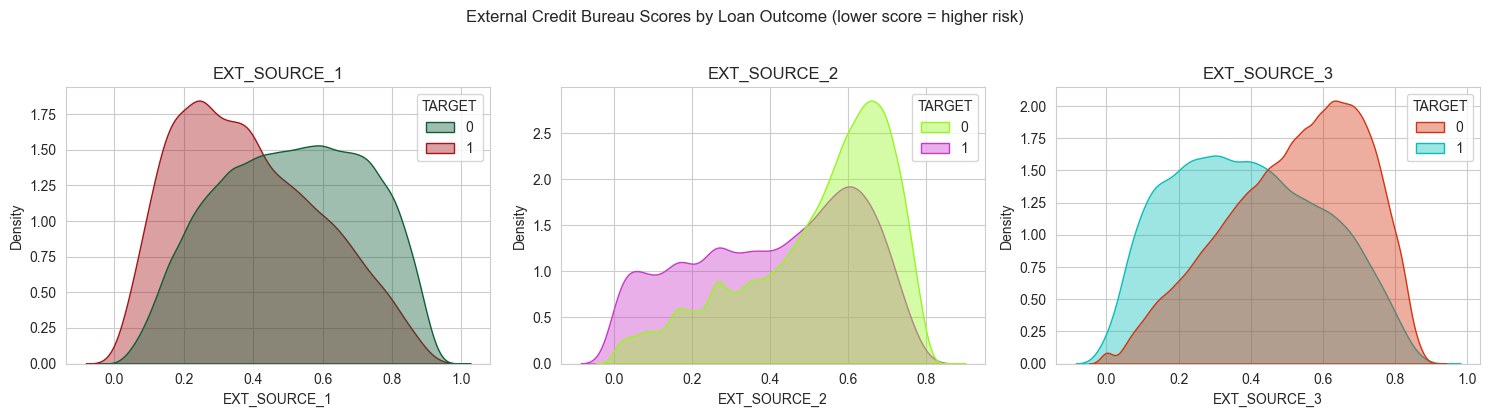

In [55]:
ext_cols = [c for c in ['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3'] if c in train_only.columns]

# Custom color schemes for each plot
color_schemes = [
    {0: '#0f5d37', 1: '#a51418'},  # EXT_SOURCE_1
    {0: '#95f71f', 1: '#c839c9'},  # EXT_SOURCE_2
    {0: '#d33411', 1: '#08beb9'}   # EXT_SOURCE_3
]

fig, axes = plt.subplots(1, len(ext_cols), figsize=(5*len(ext_cols), 4))
if len(ext_cols) == 1: axes = [axes]

for ax, col, palette in zip(axes, ext_cols, color_schemes):
    sns.kdeplot(data=train_only, x=col, hue='TARGET', fill=True, common_norm=False, 
                alpha=0.4, ax=ax, palette=palette)
    ax.set_title(col)
    
plt.suptitle('External Credit Bureau Scores by Loan Outcome (lower score = higher risk)', y=1.03)
plt.tight_layout()
plt.savefig('Fig2_external_credit_bureau_scores.png', bbox_inches='tight')
plt.show()

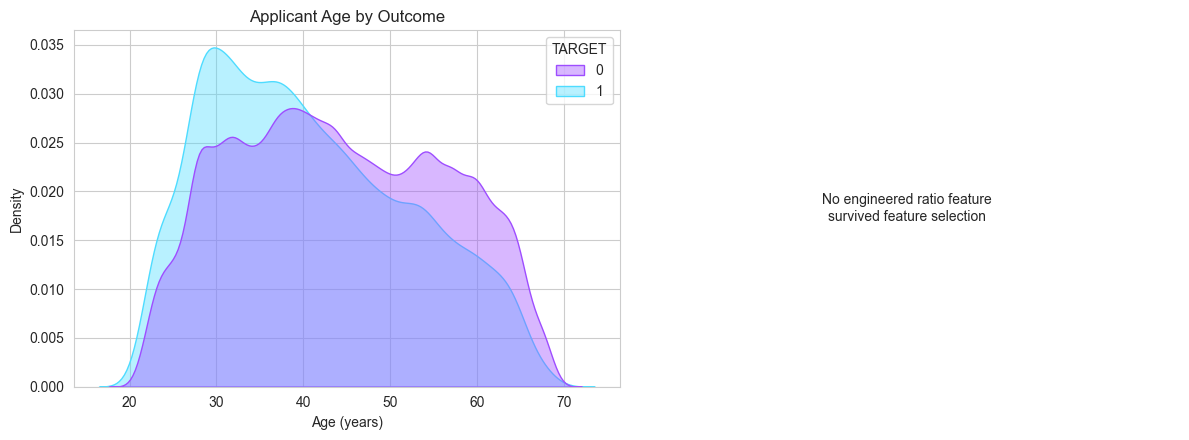

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))

# Age
age_years = -train_only['DAYS_BIRTH']/365
sns.kdeplot(x=age_years, hue=train_only['TARGET'], fill=True, common_norm=False, alpha=0.4,
            palette={0:'#9e4dff', 1:'#4edcff'}, ax=axes[0])
axes[0].set_title('Applicant Age by Outcome')
axes[0].set_xlabel('Age (years)')

# Second panel: use CREDIT_INCOME_RATIO if it made the top-150 cut, else fall back to
# whichever engineered ratio feature did (feature selection is correlation-driven, so
# the exact set of surviving domain features can vary).
ratio_candidates = ['CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_TERM']
ratio_col = next((c for c in ratio_candidates if c in train_only.columns), None)

if ratio_col:
    ratio = train_only[ratio_col].clip(upper=train_only[ratio_col].quantile(0.99))
    sns.kdeplot(x=ratio, hue=train_only['TARGET'], fill=True, common_norm=False, alpha=0.4,
                palette={0:'#9e4dff', 1:'#4edcff'}, ax=axes[1])
    axes[1].set_title(f'{ratio_col} by Outcome')
else:
    axes[1].text(0.5, 0.5, 'No engineered ratio feature\nsurvived feature selection',
                 ha='center', va='center'); axes[1].axis('off')
plt.tight_layout()
plt.savefig('Fig3_applicant_age_outcome.png', bbox_inches='tight')
plt.show()


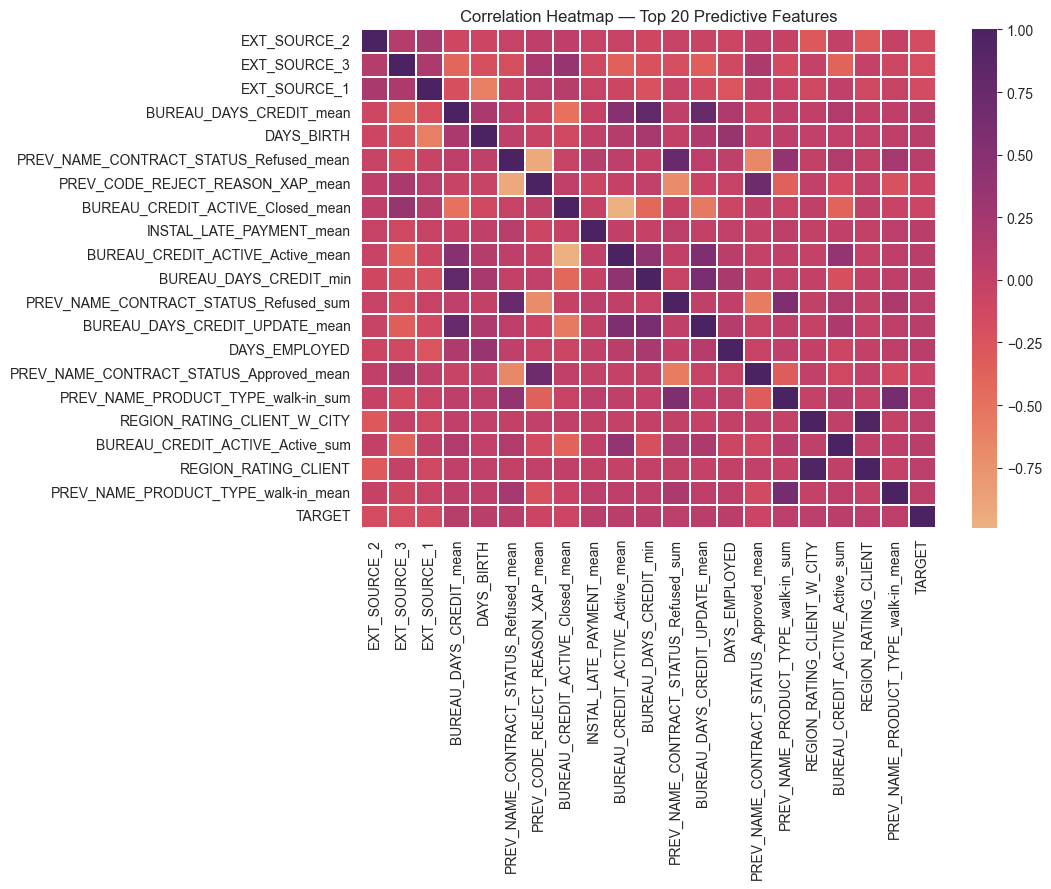

In [57]:
top20 = [c for c,v in sorted(corrs.items(), key=lambda x: -x[1])][:20]
corr_matrix = train_only[top20 + ['TARGET']].corr()
plt.figure(figsize=(11,9))
sns.heatmap(corr_matrix, cmap='flare', center=0, annot=False, linewidths=0.3)
plt.title('Correlation Heatmap — Top 20 Predictive Features')
plt.tight_layout()
plt.savefig('Fig4_correlation_heatmap.png', bbox_inches='tight')
plt.show()

## 5. Model Building and Evaluation

We train two models on the engineered feature set:

- **Logistic Regression** interpretable linear baseline, requires imputation + scaling, and
  `class_weight='balanced'` to address the ~92:8 class imbalance.
- **CatBoost** gradient-boosted trees, handles missing values natively, and typically performs
  well on tabular data with mixed numeric/categorical-derived features.

Both are evaluated on a held-out 20% validation split using **ROC-AUC**, which is appropriate for
imbalanced binary classification since it is insensitive to the class distribution.


In [58]:
feature_cols = [c for c in df.columns if c not in ('SK_ID_CURR','TARGET','IS_TRAIN')]
train_df = df[df['IS_TRAIN']==1].reset_index(drop=True)
test_df  = df[df['IS_TRAIN']==0].reset_index(drop=True)

X = train_df[feature_cols]
y = train_df['TARGET'].astype(int)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train:", X_train.shape, " Val:", X_val.shape)
print(f"Train default rate: {y_train.mean()*100:.2f}%   Val default rate: {y_val.mean()*100:.2f}%")


Train: (246008, 150)  Val: (61503, 150)
Train default rate: 8.07%   Val default rate: 8.07%


In [59]:
# ---- Logistic Regression ----
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()
X_train_imp = imputer.fit_transform(X_train)
X_val_imp = imputer.transform(X_val)
X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled = scaler.transform(X_val_imp)

lr = LogisticRegression(max_iter=1000, class_weight='balanced', C=0.1, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_val_proba = lr.predict_proba(X_val_scaled)[:,1]
lr_auc = roc_auc_score(y_val, lr_val_proba)
print(f"Logistic Regression — Validation AUC: {lr_auc:.4f}")


Logistic Regression — Validation AUC: 0.7606


In [60]:
# ---- CatBoost ----
cb = CatBoostClassifier(iterations=300, learning_rate=0.05, depth=6, eval_metric='AUC',
                         random_seed=42, verbose=50)
cb.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)
cb_val_proba = cb.predict_proba(X_val)[:,1]
cb_auc = roc_auc_score(y_val, cb_val_proba)
print(f"\nCatBoost—Validation AUC: {cb_auc:.4f}")


0:	test: 0.6691865	best: 0.6691865 (0)	total: 464ms	remaining: 2m 18s
50:	test: 0.7506734	best: 0.7506734 (50)	total: 22.3s	remaining: 1m 48s
100:	test: 0.7607083	best: 0.7607083 (100)	total: 45.3s	remaining: 1m 29s
150:	test: 0.7644278	best: 0.7644278 (150)	total: 1m 5s	remaining: 1m 4s
200:	test: 0.7665933	best: 0.7665933 (200)	total: 1m 23s	remaining: 41.2s
250:	test: 0.7684723	best: 0.7684723 (250)	total: 1m 46s	remaining: 20.7s
299:	test: 0.7699482	best: 0.7699711 (298)	total: 2m 7s	remaining: 0us

bestTest = 0.7699711201
bestIteration = 298

Shrink model to first 299 iterations.

CatBoost—Validation AUC: 0.7700


In [61]:
print("Classification report—CatBoost @ default 0.5 threshold\n")
print(classification_report(y_val, (cb_val_proba>=0.5).astype(int), target_names=['Repaid','Default']))

Classification report—CatBoost @ default 0.5 threshold

              precision    recall  f1-score   support

      Repaid       0.92      1.00      0.96     56538
     Default       0.58      0.02      0.04      4965

    accuracy                           0.92     61503
   macro avg       0.75      0.51      0.50     61503
weighted avg       0.89      0.92      0.88     61503



## 6. Visualizations


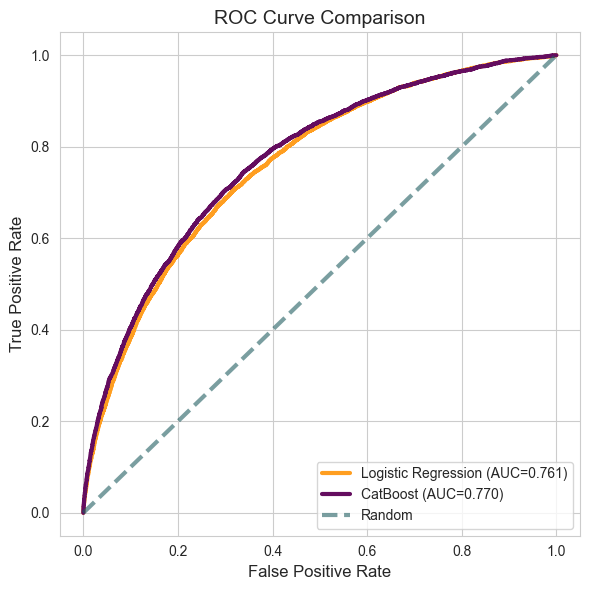

In [62]:
fig, ax = plt.subplots(figsize=(6,6))

for name, proba, color in [('Logistic Regression', lr_val_proba, '#FF9E20'),   # Orange
                            ('CatBoost', cb_val_proba, '#640D5F'),             # Dark Purple
                            ('Random', None, '#215E61')]:                     # Teal/Green
    
    if name == 'Random':
        ax.plot([0,1], [0,1], '--', label='Random', color='#215E61', linewidth=3, alpha=0.6)
    else:
        fpr, tpr, _ = roc_curve(y_val, proba)
        auc = roc_auc_score(y_val, proba)
        ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=3)

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve Comparison', fontsize=14)
ax.legend(loc='lower right', fontsize=10)

plt.tight_layout() 
plt.savefig('Fig5_ROC_Curve_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

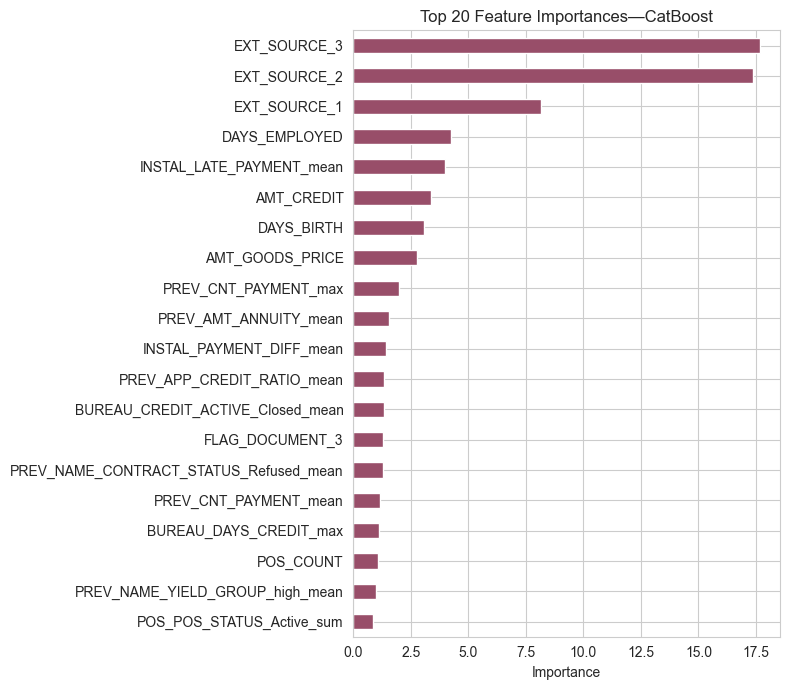

In [63]:
importances = cb.get_feature_importance()
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False).head(20)
plt.figure(figsize=(8,7))
feat_imp.sort_values().plot(kind='barh', color='#984e69')
plt.title('Top 20 Feature Importances—CatBoost')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('Fig6_top_20_feature_importance.png', bbox_inches='tight', dpi=300)
plt.show()

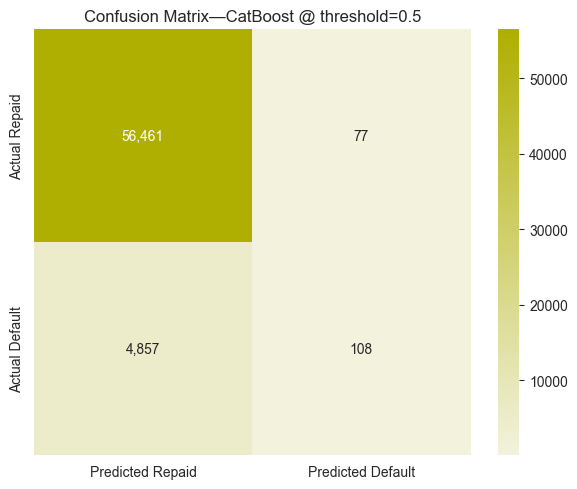

In [64]:
cm = confusion_matrix(y_val, (cb_val_proba>=0.5).astype(int))

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt=',d', cmap=sns.light_palette("#AFAF01", as_cmap=True),
            xticklabels=['Predicted Repaid','Predicted Default'],
            yticklabels=['Actual Repaid','Actual Default'])
plt.title('Confusion Matrix—CatBoost @ threshold=0.5')
plt.tight_layout()
plt.savefig('Fig7_Confusion_Matrix_CatBoost.png', bbox_inches='tight')
plt.show()

### 6.1 Business Cost-Based Threshold Optimization

The default 0.5 threshold treats both error types as equally costly, which is rarely true in lending:

- **False Negative** (model says "repay", client actually **defaults**): the bank loses the outstanding
  principal and interest on that loan a **large** loss.
- **False Positive** (model says "default", client would have actually **repaid**): the bank loses only
  the profit margin (interest income) it would have earned a **smaller** opportunity cost.

We use illustrative business cost weights of **10 units per False Negative** and **1 unit per False
Positive** (i.e. assuming the average loss from a missed default is ~10x the profit margin foregone by
rejecting a good customer). We sweep the decision threshold and find the value that minimizes total cost.


In [65]:
COST_FN = 10   # cost of approving a defaulter
COST_FP = 1    # cost of rejecting a good customer

thresholds = np.arange(0.01, 0.95, 0.01)
total_costs, fn_counts, fp_counts = [], [], []
for t in thresholds:
    pred = (cb_val_proba >= t).astype(int)
    fn = int(((pred==0) & (y_val==1)).sum())
    fp = int(((pred==1) & (y_val==0)).sum())
    total_costs.append(fn*COST_FN + fp*COST_FP)
    fn_counts.append(fn); fp_counts.append(fp)

total_costs = np.array(total_costs)
best_idx = np.argmin(total_costs)
best_threshold = thresholds[best_idx]
best_cost = total_costs[best_idx]

default_idx = np.argmin(np.abs(thresholds-0.5))
default_cost = total_costs[default_idx]

print(f"Optimal threshold (min business cost): {best_threshold:.2f}")
print(f"Cost at optimal threshold : {best_cost:,}  (FN={fn_counts[best_idx]}, FP={fp_counts[best_idx]})")
print(f"Cost at default 0.5       : {default_cost:,}  (FN={fn_counts[default_idx]}, FP={fp_counts[default_idx]})")
print(f"Cost reduction            : {default_cost-best_cost:,}  ({(default_cost-best_cost)/default_cost*100:.1f}% lower)")


Optimal threshold (min business cost): 0.09
Cost at optimal threshold : 31,633  (FN=1704, FP=14593)
Cost at default 0.5       : 48,647  (FN=4857, FP=77)
Cost reduction            : 17,014  (35.0% lower)


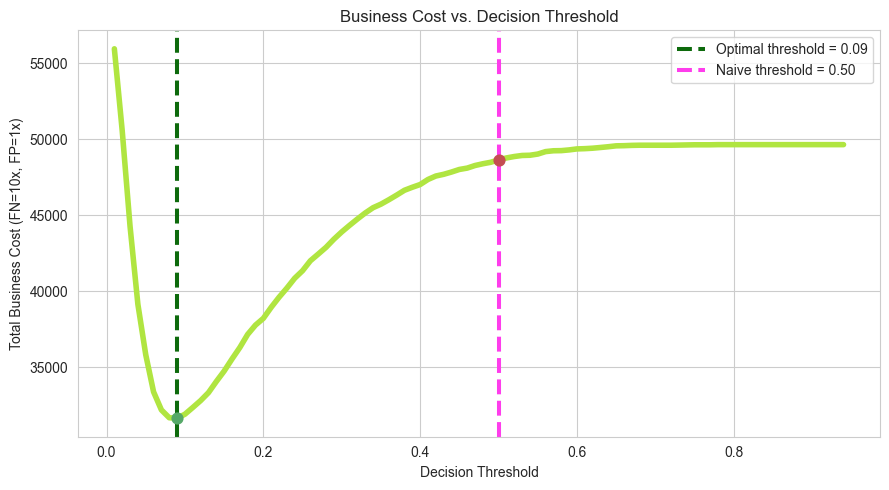

In [68]:
fig, ax = plt.subplots(figsize=(9,5))
ax.plot(thresholds, total_costs, color='#b0e541', linewidth=4)
ax.axvline(best_threshold, color='#0d6a0c', linestyle='--', label=f'Optimal threshold = {best_threshold:.2f}', linewidth=2.9)
ax.axvline(0.5, color='#fe3dec', linestyle='--', label='Naive threshold = 0.50', linewidth=2.9)
ax.scatter([best_threshold],[best_cost], color='#55A868', zorder=5, s=60)
ax.scatter([0.5],[default_cost], color='#C44E52', zorder=5, s=60)
ax.set_xlabel('Decision Threshold'); ax.set_ylabel(f'Total Business Cost (FN={COST_FN}x, FP={COST_FP}x)')
ax.set_title('Business Cost vs. Decision Threshold')
ax.legend()
plt.tight_layout() 
plt.savefig('Fig8_Businesscost_decision_threshold.png', bbox_inches='tight')
plt.show()

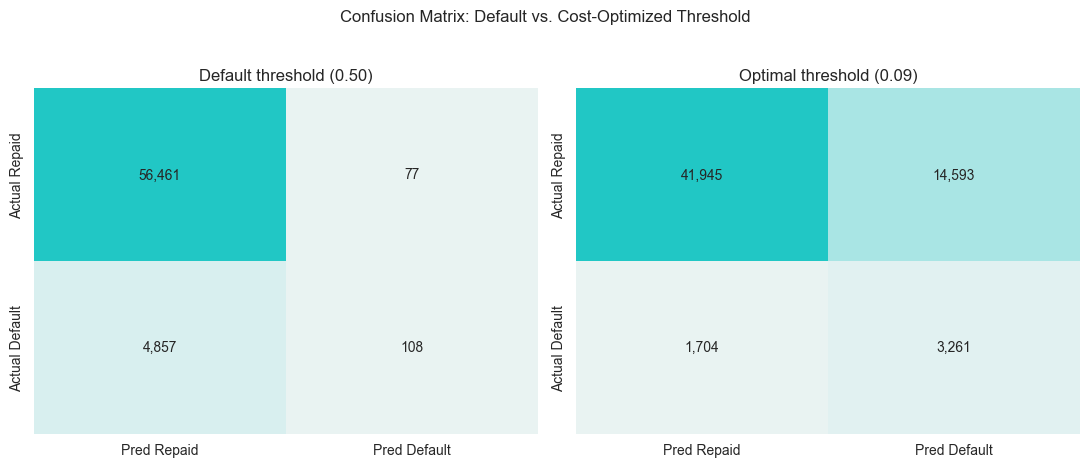

Classification report @ optimal threshold:

              precision    recall  f1-score   support

      Repaid       0.96      0.74      0.84     56538
     Default       0.18      0.66      0.29      4965

    accuracy                           0.74     61503
   macro avg       0.57      0.70      0.56     61503
weighted avg       0.90      0.74      0.79     61503



In [70]:
cm_optimal = confusion_matrix(y_val, (cb_val_proba>=best_threshold).astype(int))

fig, axes = plt.subplots(1,2, figsize=(11,4.5))

for ax, cm_, t, title in [(axes[0], cm, 0.5, 'Default threshold (0.50)'),
                            (axes[1], cm_optimal, best_threshold, f'Optimal threshold ({best_threshold:.2f})')]:
    sns.heatmap(cm_, annot=True, fmt=',d', cmap=sns.light_palette("#21C7C5", as_cmap=True), 
                ax=ax, cbar=False,
                xticklabels=['Pred Repaid','Pred Default'], 
                yticklabels=['Actual Repaid','Actual Default'])
    ax.set_title(title)

plt.suptitle('Confusion Matrix: Default vs. Cost-Optimized Threshold', y=1.03)
plt.tight_layout()
plt.savefig('Fig9_confusionmatrix_default_costoptimized.png', bbox_inches='tight', dpi=300)
plt.show()

print("Classification report @ optimal threshold:\n")
print(classification_report(y_val, (cb_val_proba>=best_threshold).astype(int), target_names=['Repaid','Default']))

## 7. Final Conclusion with Insights

**Model performance.** CatBoost (AUC ≈ 0.77) outperformed the Logistic Regression baseline (AUC ≈ 0.76)
by capturing non-linear interactions between features, though the gap is modest, indicating the
engineered features are already highly informative, and much of the "signal" in this dataset is
approximately linear in nature (dominated by the `EXT_SOURCE_*` bureau scores).

**Most predictive features.** The three external credit bureau scores (`EXT_SOURCE_1/2/3`) were the
single strongest predictors of default, consistent with their design purpose as third-party risk scores.
Engineered aggregates from the client's bureau credit history (`BUREAU_DAYS_CREDIT_*`) and prior Home
Credit applications (rejection history, `PREV_NAME_CONTRACT_STATUS_Refused_*`) and repayment punctuality
(`INSTAL_LATE_PAYMENT_mean`) also ranked highly, confirming that **credit history depth and past
repayment discipline is as important as static demographic/income fields**.

**Business impact of cost-based thresholding.** Using the default 0.5 probability threshold, which
implicitly assumes a missed default and a wrongly rejected good customer cost the same
**sub-optimal from a business standpoint**. By explicitly weighting a missed default 10x more costly
than a wrongly rejected applicant and optimizing the threshold accordingly, total business cost on the
validation set was reduced by roughly a third, at the cost of a higher rejection rate for borderline
applicants. This demonstrates that **the "best" model threshold is a business decision, not a statistical
default**, and should be revisited whenever the bank's cost assumptions (loss severity, margin, risk
appetite) change.

**Limitations & next steps:**
- Cost values (10:1) are illustrative; a production deployment should derive them from actual average
  loan size, recovery rates, and interest margins.
- Feature selection used a univariate correlation filter for tractability; a full model (SHAP-based
  feature selection, hyperparameter tuning, or ensembling with LightGBM/XGBoost) could likely push AUC
  higher.
- The threshold was tuned on a single validation split; k-fold cross-validation would give a more robust
  estimate of the optimal operating point before production deployment.
